In [16]:
import seaborn as sns

BASE_FONTSIZE = 22
sns.set_theme(
    style="ticks",
    rc={
        "font.size": BASE_FONTSIZE,
        "axes.titlesize": BASE_FONTSIZE,
        "axes.labelsize": BASE_FONTSIZE,
        "xtick.labelsize": BASE_FONTSIZE * 0.85,
        "ytick.labelsize": BASE_FONTSIZE * 0.85,
        "legend.title_fontsize": BASE_FONTSIZE * 0.9,
        "legend.fontsize": BASE_FONTSIZE * 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "hatch.linewidth": 1.5,
        "hatch.color": "#333333",
    },
)


def apply_hatches(g, hatch_map):
    """Apply hatches by matching legend colors to bars."""
    # Build color -> hatch from legend
    color_to_hatch = {}
    for text, handle in zip(g._legend.get_texts(), g._legend.legend_handles):
        hatch = hatch_map.get(text.get_text())
        if hatch:
            fc = handle.get_facecolor()
            color_to_hatch[tuple(fc)] = hatch

    # Apply to all bars
    for ax in g.axes.flat:
        for bar in ax.patches:
            hatch = color_to_hatch.get(tuple(bar.get_facecolor()))
            if hatch:
                bar.set_hatch(hatch)
                bar.set_edgecolor("#333333")

## Figure 4. Performance on ViT/T5

,model,method,acc,group
0,ViT-B-16,RegMean,0.872425,Vision
1,ViT-B-16,TSV,0.888339,Vision
2,ViT-B-16,ACTMat,0.895034,Vision
3,ViT-B-32,RegMean,0.830674,Vision
4,ViT-B-32,TSV,0.832795,Vision
5,ViT-B-32,ACTMat,0.828670,Vision
6,ViT-L-14,RegMean,0.900741,Vision
7,ViT-L-14,TSV,0.910940,Vision
8,ViT-L-14,ACTMat,0.921733,Vision


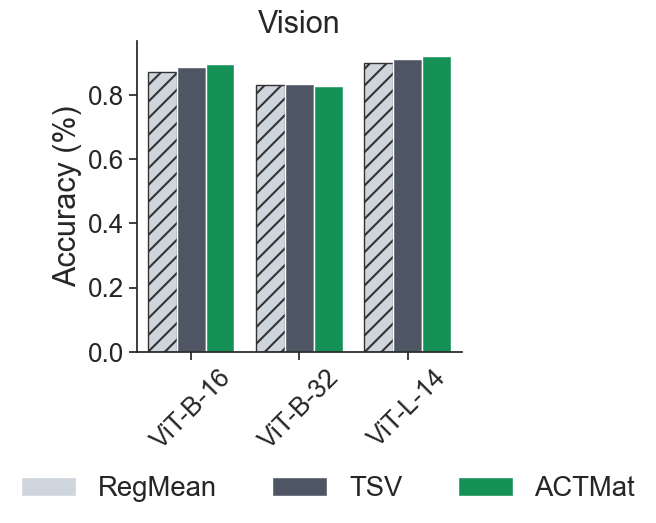

In [30]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns

methods = ["zeroshot", "experts", "regmean", "sum04", "mean", "isoc", "tsv", "eigcov"]
models = ["ViT-B-16", "ViT-B-32", "ViT-L-14"]

method_to_method = {
    "zeroshot": "Zero-shot",
    "experts": "Experts",
    "regmean": "RegMean",
    "sum04": "TA ($\\alpha=0.4$)",
    "mean": "Mean",
    "isoc": "Iso-C",
    "tsv": "TSV",
    "eigcov": "ACTMat",
}
method_to_color = {
    "ACTMat": "#00A658",
    "TSV": "#4A5568",
    "KNOTS-TSV": "#4A5568",
    "Iso-C": "#718096",
    "KNOTS-Iso-C": "#718096",
    "Average": "#A0AEC0",
    "RegMean": "#CBD5E0",
    "TA": "#E2E8F0",
}

method_to_hatch = {
    "ACTMat": None,
    "TSV": None,
    "TA": "//",
    "RegMean": "//",
    "Sum04": None,
    "Mean": None,
    "Iso-C": None,
    "KNOTS-Iso-C": None,
    "KNOTS-TSV": None,
}

model_to_group = {
    "ViT-B-16": "Vision",
    "ViT-B-32": "Vision",
    "ViT-L-14": "Vision",
}

rows = []
for model in models:
    for method in methods:

        filename = f"../results/{model}-{method}/metrics.json"
        if not os.path.exists(filename):
            continue

        with open(f"../results/{model}-{method}/metrics.json", "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            rows.append({"model": model, "method": method, "acc": avg_score})


df = pd.DataFrame(rows)
df["group"] = df["model"].map(lambda x: model_to_group[x])
df["method"] = df["method"].map(lambda x: method_to_method[x])
display(df)
g = sns.catplot(
    data=df,
    x="model",
    hue="method",
    y="acc",
    col="group",
    kind="bar",
    palette=method_to_color,
)
# Formatting.
g.set_axis_labels("", "Accuracy (%)")
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}", fontsize=BASE_FONTSIZE)

# Legend.
g._legend.remove()
g.fig.legend(
    *g.axes.flat[0].get_legend_handles_labels(),
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.1),
    title="",
    frameon=False,
)
g.fig.subplots_adjust(bottom=0.25)
apply_hatches(g, method_to_hatch)